# Parkinsons Disease Data Set prediction Using Ensemble Techniques

Parkinson’s Disease (PD) is a degenerative neurological disorder marked by decreased dopamine levels in the brain. It manifests itself through a deterioration of movement, including the presence of tremors and stiffness. There is commonly a marked effect on speech, including dysarthria (difficulty articulating sounds), hypophonia (lowered volume), and monotone (reduced pitch range). Additionally, cognitive impairments and changes in mood can occur, and risk of dementia is increased.

Traditional diagnosis of Parkinson’s Disease involves a clinician taking a neurological history of the patient and observing motor skills in various situations. Since there is no definitive laboratory test to diagnose PD, diagnosis is often difficult, particularly in the early stages when motor effects are not yet severe. Monitoring progression of the disease over time requires repeated clinic visits by the patient. An effective screening process, particularly one that doesn’t require a clinic visit, would be beneficial. Since PD patients exhibit characteristic vocal features, voice recordings are a useful and non-invasive tool for diagnosis. If machine learning algorithms could be applied to a voice recording dataset to accurately diagnosis PD, this would be an effective screening step prior to an appointment with a clinician.

The data & attributes information for this project is available at https://archive.ics.uci.edu/ml/machine-learning-databases/parkinsons/ (Links to an external site.)Links to an external site. The data consists of those diagnosed with Parkinson Disease and those who do not.

In [57]:
import pandas as pd
import numpy as np
from os import system
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from sklearn import metrics
from IPython.display import Image 
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB as gnb
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Use a Python notebook & Load the dataset

In [2]:
data = pd.read_csv('parkinsons.data')

# Eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. (2.5 points)

**Dataset Information:**

This dataset is composed of a range of biomedical voice measurements from 31 people, 23 with Parkinson's disease (PD). Each column in the table is a particular voice measure, and each row corresponds one of 195 voice recording from these individuals ("name" column). The main aim of the data is to discriminate healthy people from those with PD, according to "status" column which is set to 0 for healthy and 1 for PD.

The data is in ASCII CSV format. The rows of the CSV file contain an instance corresponding to one voice recording. There are around six recordings per patient, the name of the patient is identified in the first column.

**Attribute Information:**

* name - ASCII subject name and recording number
* MDVP:Fo(Hz) - Average vocal fundamental frequency
* MDVP:Fhi(Hz) - Maximum vocal fundamental frequency
* MDVP:Flo(Hz) - Minimum vocal fundamental frequency
* MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP - Several measures of variation in fundamental frequency
* MDVP:Shimmer,MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA - Several measures of variation in amplitude
* NHR,HNR - Two measures of ratio of noise to tonal components in the voice 
* status - Health status of the subject (one) - Parkinson's, (zero) - healthy
* RPDE,D2 - Two nonlinear dynamical complexity measures
* DFA - Signal fractal scaling exponent
* spread1,spread2,PPE - Three nonlinear measures of fundamental frequency variation 

In [3]:
data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [4]:
data.shape

(195, 24)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
name                195 non-null object
MDVP:Fo(Hz)         195 non-null float64
MDVP:Fhi(Hz)        195 non-null float64
MDVP:Flo(Hz)        195 non-null float64
MDVP:Jitter(%)      195 non-null float64
MDVP:Jitter(Abs)    195 non-null float64
MDVP:RAP            195 non-null float64
MDVP:PPQ            195 non-null float64
Jitter:DDP          195 non-null float64
MDVP:Shimmer        195 non-null float64
MDVP:Shimmer(dB)    195 non-null float64
Shimmer:APQ3        195 non-null float64
Shimmer:APQ5        195 non-null float64
MDVP:APQ            195 non-null float64
Shimmer:DDA         195 non-null float64
NHR                 195 non-null float64
HNR                 195 non-null float64
status              195 non-null int64
RPDE                195 non-null float64
DFA                 195 non-null float64
spread1             195 non-null float64
spread2             195 non-null floa

In [6]:
#moving status column to the last
df1=data.pop('status')
data['status'] = df1

In [7]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MDVP:Fo(Hz),195.0,154.228641,41.390065,88.333000,117.572000,148.790000,182.769000,260.105000
MDVP:Fhi(Hz),195.0,197.104918,91.491548,102.145000,134.862500,175.829000,224.205500,592.030000
MDVP:Flo(Hz),195.0,116.324631,43.521413,65.476000,84.291000,104.315000,140.018500,239.170000
MDVP:Jitter(%),195.0,0.006220,0.004848,0.001680,0.003460,0.004940,0.007365,0.033160
MDVP:Jitter(Abs),195.0,0.000044,0.000035,0.000007,0.000020,0.000030,0.000060,0.000260
MDVP:RAP,195.0,0.003306,0.002968,0.000680,0.001660,0.002500,0.003835,0.021440
MDVP:PPQ,195.0,0.003446,0.002759,0.000920,0.001860,0.002690,0.003955,0.019580
Jitter:DDP,195.0,0.009920,0.008903,0.002040,0.004985,0.007490,0.011505,0.064330
MDVP:Shimmer,195.0,0.029709,0.018857,0.009540,0.016505,0.022970,0.037885,0.119080
MDVP:Shimmer(dB),195.0,0.282251,0.194877,0.085000,0.148500,0.221000,0.350000,1.302000


In [8]:
data.status.value_counts()

1    147
0     48
Name: status, dtype: int64

There are 147 people affected with PD

The name feature is not required for analysis, so we can drop this.

In [9]:
data = data.drop('name', axis=1)

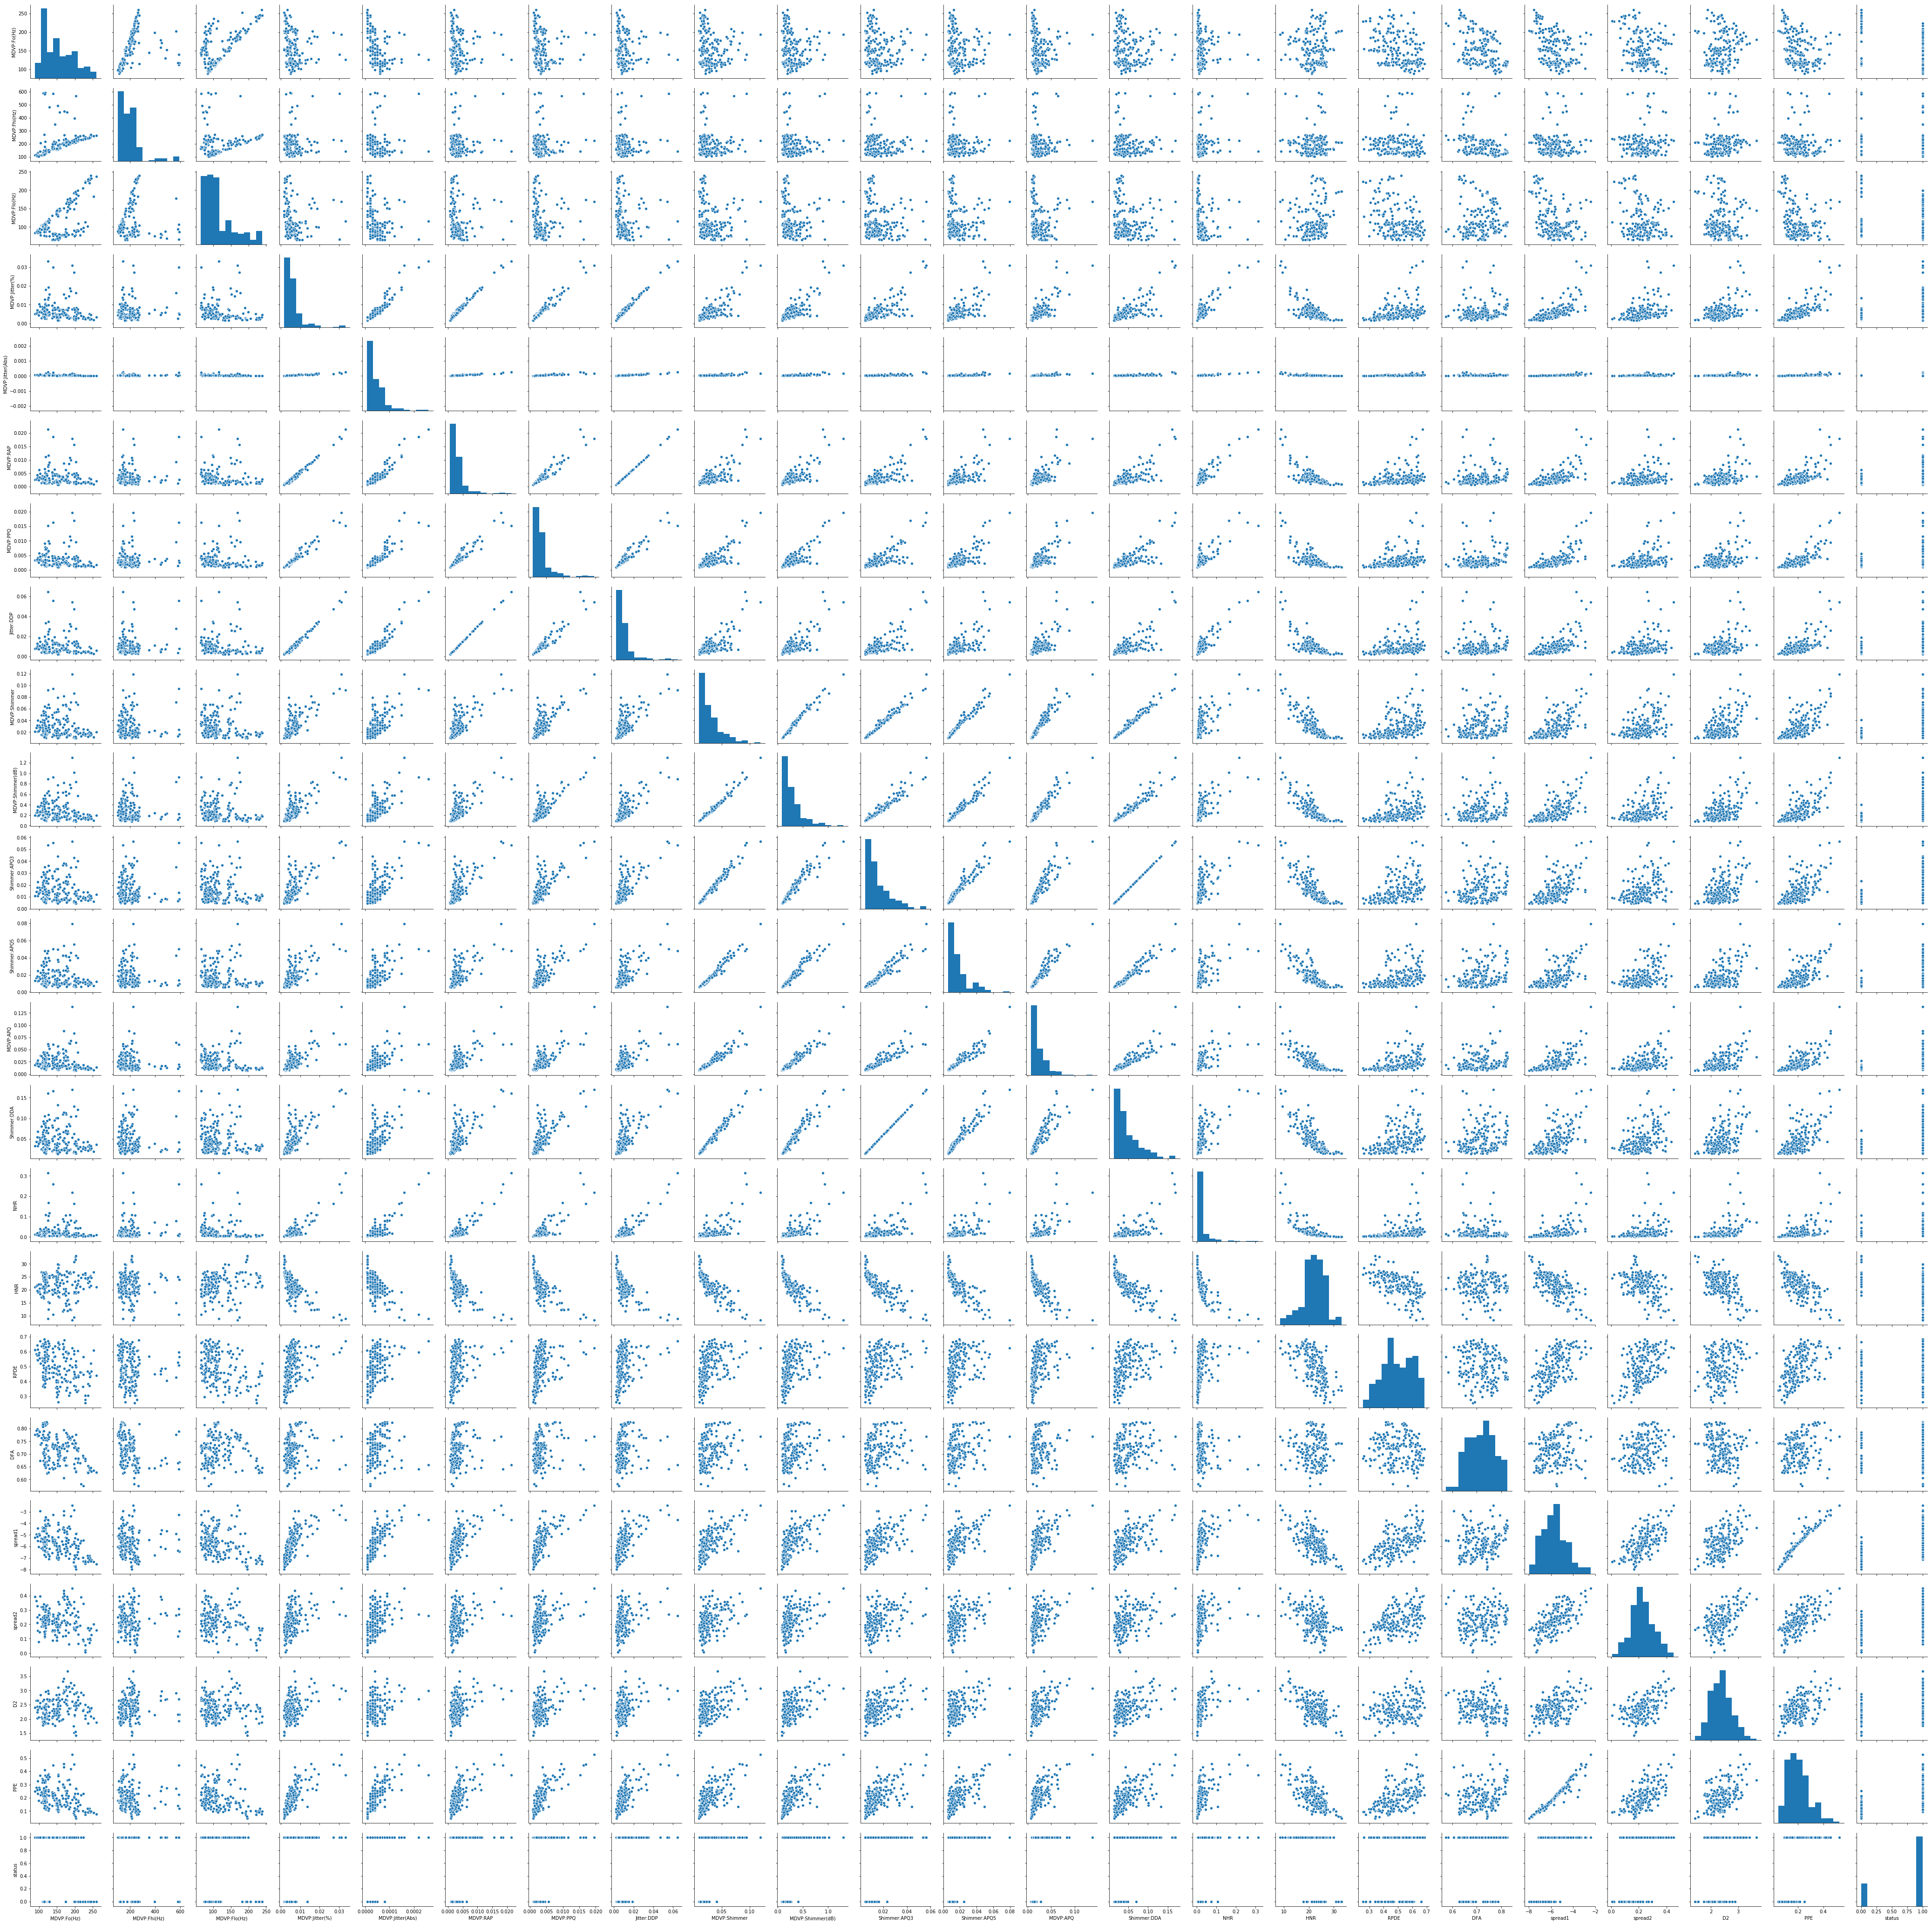

In [24]:
sns.pairplot(data)

# Using univariate & bivariate analysis to check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations? (15 points)

## Univariate Analysis

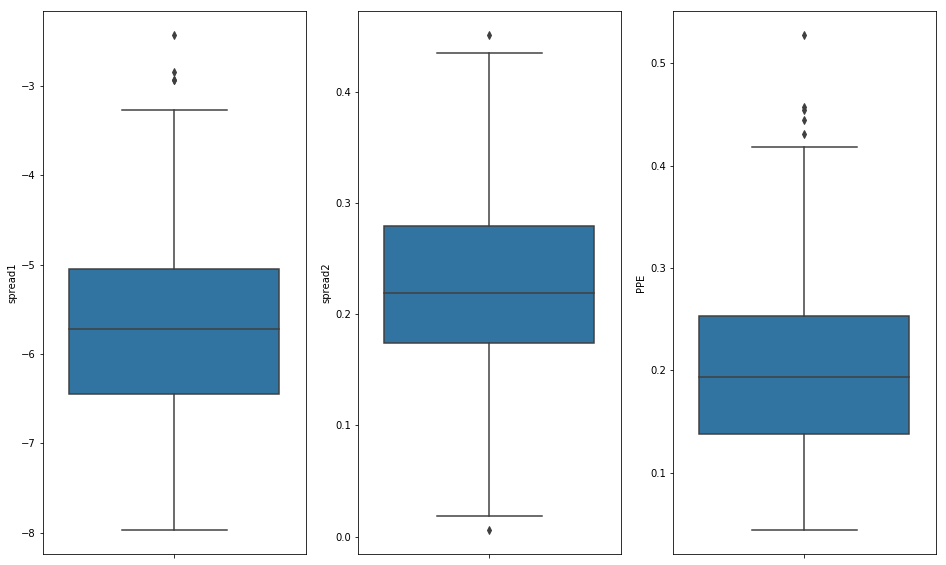

In [10]:
fig, ax = plt.subplots(1,3,figsize=(16,10))
sns.boxplot(x='spread1',data=data, ax=ax[0],orient='v')
sns.boxplot(x='spread2',data=data, ax=ax[1],orient='v')
sns.boxplot(x='PPE',data=data, ax=ax[2],orient='v')

The above figure shows the box plot of the frequency variation. All the three variations have outliers.

Generally speaking, decision trees will be able to handle datsets with outliers more efficiently. It is very unlikely that decision tree will create a leaf to isolate them

/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


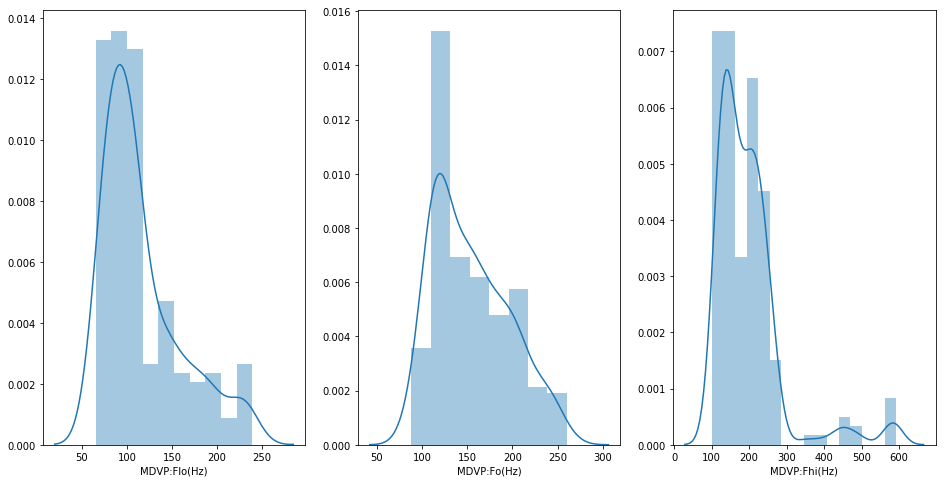

In [11]:
fig, ax = plt.subplots(1,3,figsize=(16,8))
sns.distplot(data['MDVP:Flo(Hz)'],ax=ax[0])
sns.distplot(data['MDVP:Fo(Hz)'],ax=ax[1])
sns.distplot(data['MDVP:Fhi(Hz)'],ax=ax[2])

The measures of vocal fundamental frequency are shown above. There is a positive skewness for minimum vocal fundemental frequency with more high values between 75Hz and 125Hhz. The average vocal frequency is almost normally distributed with more values ranging 115Hz and 130Hz. The high vocal frequency does not have any skewness, but some range of values are at the right most tail

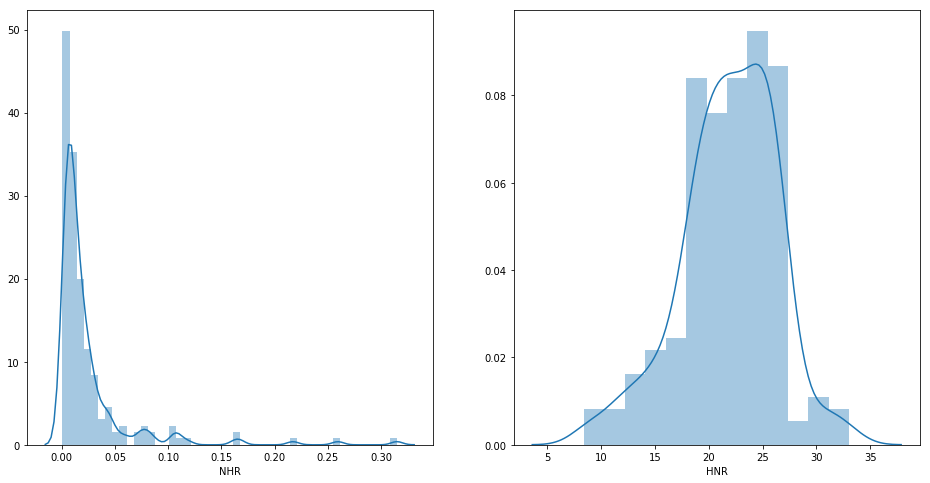

In [12]:
fig, ax = plt.subplots(1,2,figsize=(16,8))
sns.distplot(data['NHR'],ax=ax[0])
sns.distplot(data['HNR'],ax=ax[1])

The measure of tonal component of frequency is shown above. The value NHR is right skewed for there are so many observations in the area, but they seem to be with very minimal values. The maximum number of observations is between 0 and 0.04.

The value HNR looks like normally distributed, but in a first look there seems to be a slight negative skewness

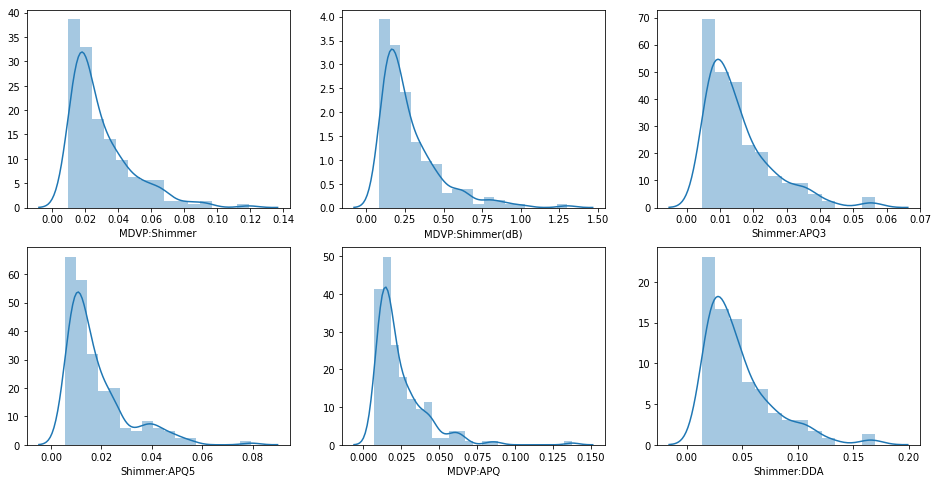

In [13]:
fig, ax = plt.subplots(2,3,figsize=(16,8))
sns.distplot(data['MDVP:Shimmer'],ax=ax[0,0])
sns.distplot(data['MDVP:Shimmer(dB)'],ax=ax[0,1])
sns.distplot(data['Shimmer:APQ3'],ax=ax[0,2])
sns.distplot(data['Shimmer:APQ5'],ax=ax[1,0])
sns.distplot(data['MDVP:APQ'],ax=ax[1,1])
sns.distplot(data['Shimmer:DDA'],ax=ax[1,2])

For all of the above graphs, we can observe that the measure of variation in amplitude is positively skewed and all of them have similar kind of distribution

# Bi -Variate Analysis
Relation between target variable and independent variables

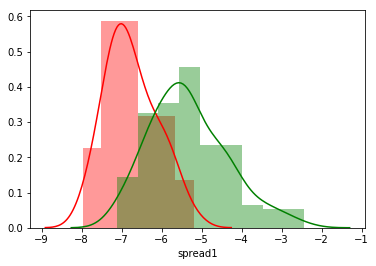

In [14]:
sns.distplot( data[data.status == 0]['spread1'], color = 'r')
sns.distplot( data[data.status == 1]['spread1'], color = 'g')

spread1 is normally distributed between person who have PD and who is normal. People who have spread1 between - 8.5 and -7.5 are more and they are normal. People whose spread1 is between -6.5 and -5 are having PD

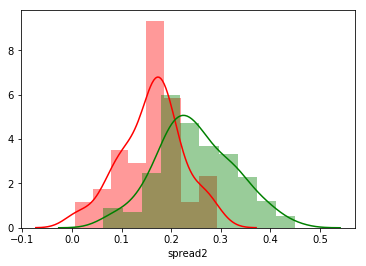

In [15]:
sns.distplot( data[data.status == 0]['spread2'], color = 'r')
sns.distplot( data[data.status == 1]['spread2'], color = 'g')

spread1 and spread2 is normally distributed. between person who have PD and who is normal. People who have spread1 between 0.15 and 0.175 are more and they are normal. People whose spread1 is between 0.175 and 0.2 are having PD

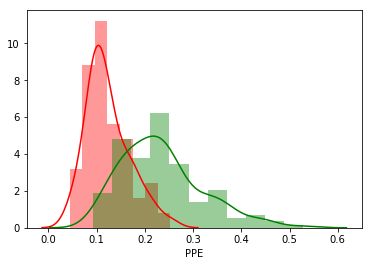

In [16]:
sns.distplot( data[data.status == 0]['PPE'], color = 'r')
sns.distplot( data[data.status == 1]['PPE'], color = 'g')

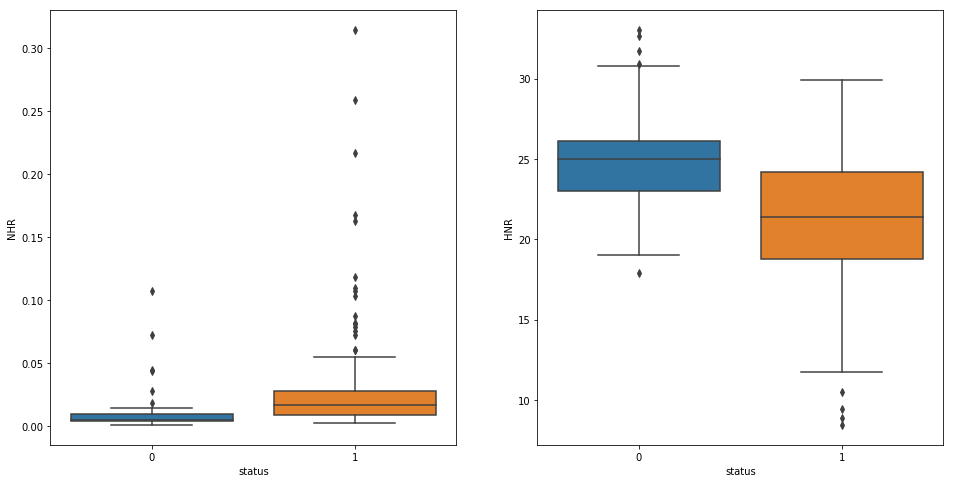

In [17]:
fig, ax = plt.subplots(1,2,figsize=(16,8))
sns.boxplot(x='status',y='NHR',data=data,ax=ax[0])
sns.boxplot(x='status',y='HNR',data=data,ax=ax[1])

People who have PD(status equal to one) have higher levels of Noise to Harmonic ratio. Also, looking into the HNR ratio people who have PD have lower levels in the same.

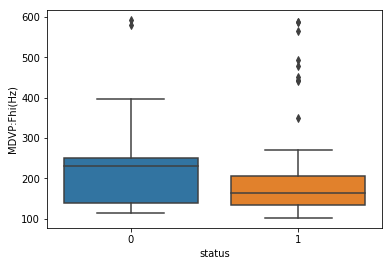

In [18]:
sns.boxplot(x='status',y='MDVP:Fhi(Hz)',data=data)

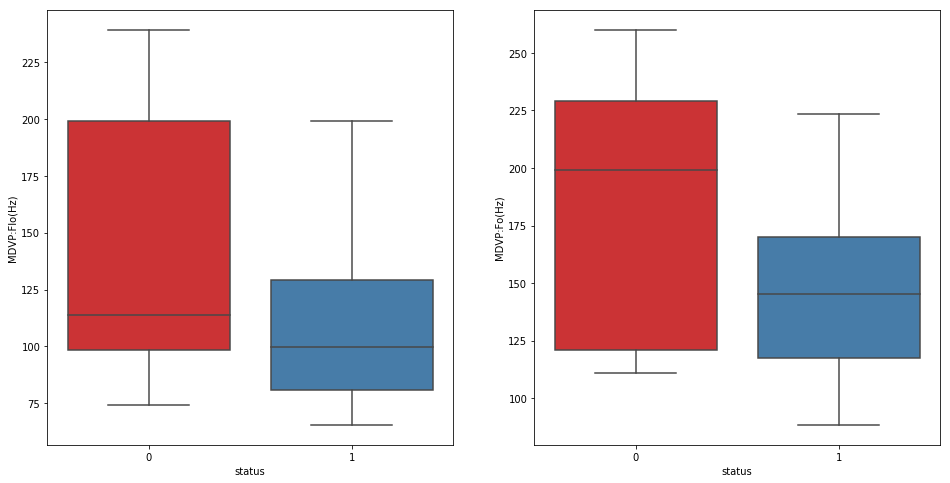

In [19]:
fig, ax = plt.subplots(1,2,figsize=(16,8))
sns.boxplot(x='status',y='MDVP:Flo(Hz)',data=data,palette="Set1",ax=ax[0])
sns.boxplot(x='status',y='MDVP:Fo(Hz)',data=data,palette="Set1",ax=ax[1])


When we look the relationship between status and MDVP:Fo(Hz) we can see the median value is around 199 Hz for people who are normal. For people who are affected with Parkinsons the median value comes around 145 Hz

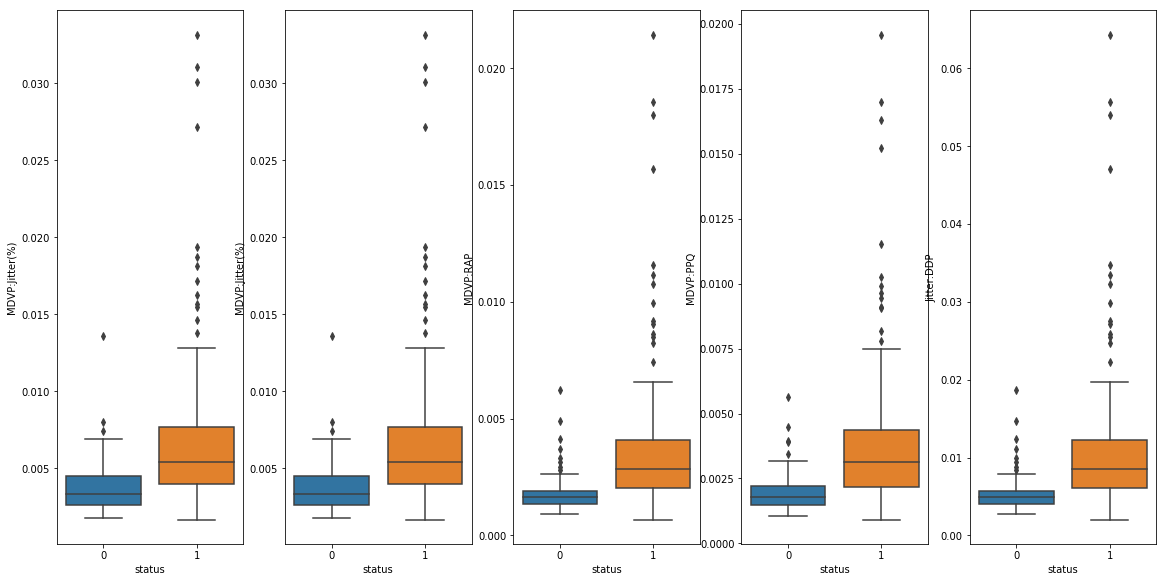

In [20]:
# For categorical predictors
cols = ["MDVP:Jitter(%)","MDVP:Jitter(%)","MDVP:RAP","MDVP:PPQ","Jitter:DDP"]
fig, axs = plt.subplots(ncols = 5,figsize=(16,8))
fig.tight_layout()
for i in range(0,len(cols)):
    sns.boxplot(x='status',y=cols[i],data=data, ax = axs[i])

People who are suffering for PD tend to have higher jitter %. It seems if the values goes above 0.15 we can confirm the patient is having PD. The variation of fundamental frequency is in a low range for people who is normal.

## Correlation comparision with heat map

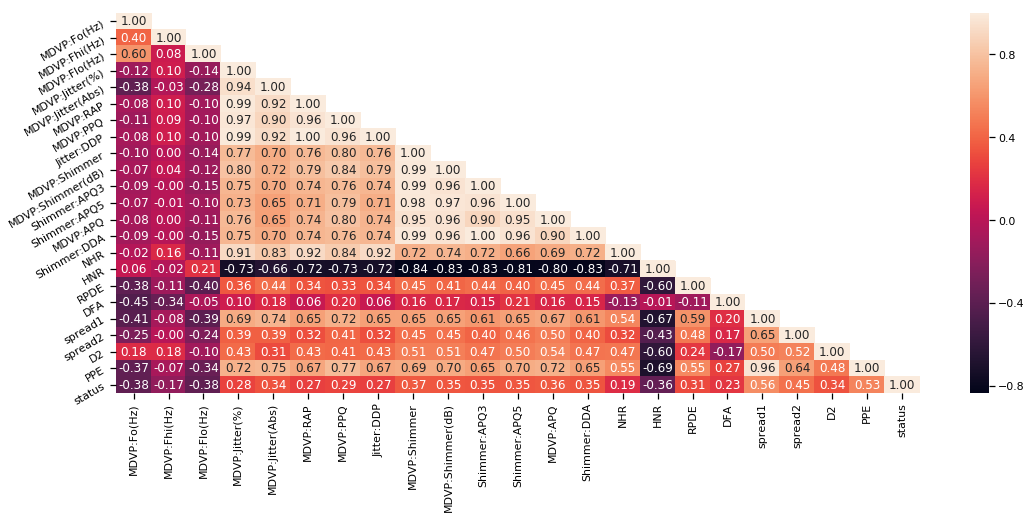

In [43]:
corr = data.corr()
sns.set_context("notebook", font_scale=1.0, rc={"lines.linewidth": 3.5})
plt.figure(figsize=(18,7))
# create a mask so we only see the correlation values once
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, 1)] = True
a = sns.heatmap(corr,mask=mask, annot=True, fmt='.2f')
rotx = a.set_xticklabels(a.get_xticklabels(), rotation=90)
roty = a.set_yticklabels(a.get_yticklabels(), rotation=30)

#MDVP:Jitter(%) has a very high correlation with MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP
#MDVP:Shimmer has a very correlation with MDVP:Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,MDVP:APQ,Shimmer:DDA
#MDVP:RAP has a very correlation with MDVP:PPQ,Jitter:DDP

The target variable status has a weak positive corelation with spread1

Drop Strongly corelated features as they will not make any difference to the prediction

In [44]:
data = data.drop(['MDVP:RAP','MDVP:PPQ','Jitter:DDP','MDVP:Shimmer(dB)',
                  'Shimmer:APQ3','Shimmer:APQ5','MDVP:APQ','Shimmer:DDA','PPE'], axis=1)

# Split the dataset into training and test set in the ratio of 70:30 (Training:Test).

In [21]:
X = data.drop("status",axis=1)
y = data["status"]
X_train, X_test, y_train,  y_test = train_test_split(X, y,train_size=0.7, test_size=0.3, random_state=42)
print(len(X_train)),print(len(X_test))

136
59


(None, None)

In [23]:
Xtrain=np.array(X_train)
ytrain=np.array(y_train)
Xtest=np.array(X_test)
ytest=np.array(y_test)

# Create the model using “entropy” method of reducing the entropy and fit it to training data. (5 points)

In [36]:
dt_model = DecisionTreeClassifier(criterion='entropy',random_state=100)

In [37]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=None,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=100,
            splitter='best')

# Test the model on test data and what is the accuracy achieved. Capture the predicted values and do a crosstab. (7.5 points)

In [38]:
y_pred = dt_model.predict(X_test)

In [39]:
confusion_matrix(y_test,y_pred)

array([[10,  5],
       [ 2, 42]])

In [40]:
dt_model.score(X_test , y_test)

0.8813559322033898

In [41]:
acc=metrics.accuracy_score(ytest,y_pred)
print(acc)

0.8813559322033898


In [42]:
cr=metrics.classification_report(ytest,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.83      0.67      0.74        15
           1       0.89      0.95      0.92        44

   micro avg       0.88      0.88      0.88        59
   macro avg       0.86      0.81      0.83        59
weighted avg       0.88      0.88      0.88        59



# Use regularization parameters of max_depth, min_sample_leaf to recreate the model. What is the impact on the model accuracy? How does regularization help? (20 points)

In [47]:
dt_model_reg = DecisionTreeClassifier(criterion='entropy',max_depth=6,random_state=100,min_samples_leaf=5)

In [49]:
dt_model_reg.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=6,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=5, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=100,
            splitter='best')

In [50]:
y_pred_reg = dt_model_reg.predict(X_test)

In [51]:
confusion_matrix(y_test,y_pred_reg)

array([[11,  4],
       [ 2, 42]])

In [53]:
dt_model_reg.score(X_test , y_test)

0.8983050847457628

In [54]:
acc=metrics.accuracy_score(ytest,y_pred_reg)
print(acc)

0.8983050847457628


In [55]:
cr=metrics.classification_report(ytest,y_pred_reg)
print(cr)

              precision    recall  f1-score   support

           0       0.85      0.73      0.79        15
           1       0.91      0.95      0.93        44

   micro avg       0.90      0.90      0.90        59
   macro avg       0.88      0.84      0.86        59
weighted avg       0.90      0.90      0.90        59



The regularization method has increased the accuracy rate sligtly. 
#Precision - False Positive ( Type I Error) has incressed with regularization 
#Recall - False Negatives (Type II Error) not much variance betweed both models
#F1Scre Maximum meanes Type 1 and 2 error togeter optimized. Regularization has helped to increase the f1 score.
But the regularization method is not helping us much in increasing the overall model performace.

# Implement the decision tree using Random Forest. What is the optimal number of trees that gives the best result? (10 points)

In [77]:
Rf_model = RandomForestClassifier(max_depth=6, n_estimators=51,criterion='entropy',random_state=0 )

In [78]:
#Perform Grid Search Method to find the optimal max_depth size
parameter={'max_depth':np.arange(1,10),'criterion' : ['entropy','gini']}
GS=GridSearchCV(dt_model,parameter,cv=3)
GS.fit(X,y)

GridSearchCV(cv=3, error_score='raise-deprecating',
       estimator=DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=6,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=5, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=100,
            splitter='best'),
       fit_params=None, iid='warn', n_jobs=None,
       param_grid={'max_depth': array([1, 2, 3, 4, 5, 6, 7, 8, 9]), 'criterion': ['entropy', 'gini']},
       pre_dispatch='2*n_jobs', refit=True, return_train_score='warn',
       scoring=None, verbose=0)

In [79]:
GS.score(Xtest,ytest)

0.9661016949152542

In [80]:
gs_pred=GS.predict(Xtest)
metrics.accuracy_score(ytest,gs_pred)

0.9661016949152542

In [81]:
GS.best_params_

{'criterion': 'entropy', 'max_depth': 4}

The optimal no of tree that give the best result is 4

In [82]:
dt_model_opt = DecisionTreeClassifier(criterion='entropy',max_depth=4,random_state=100,min_samples_leaf=5)

In [83]:
 dt_model_opt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=5, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=100,
            splitter='best')

In [84]:
y_pred_opt = dt_model_opt.predict(X_test)

In [85]:
confusion_matrix(y_test,y_pred_opt)

array([[10,  5],
       [ 2, 42]])

In [86]:
dt_model_opt.score(X_test , y_test)

0.8813559322033898

In [87]:
acc=metrics.accuracy_score(ytest,y_pred_opt)
print(acc)

0.8813559322033898


In [88]:
cr=metrics.classification_report(ytest,y_pred_opt)
print(cr)

              precision    recall  f1-score   support

           0       0.83      0.67      0.74        15
           1       0.89      0.95      0.92        44

   micro avg       0.88      0.88      0.88        59
   macro avg       0.86      0.81      0.83        59
weighted avg       0.88      0.88      0.88        59

